
# 08 · Tree models on acoustic features

Gradient-boosted trees and random forests on the acoustic feature table, evaluated on the same folds
as the neural networks so the results are directly comparable.

Four feature sets are compared, formed from two acoustic blocks with and without the GRU prediction:

| set | features |
|---|---|
| acoustic | every acoustic summary measured from the recording |
| acoustic + GRU | the same summaries plus `shannon_pred_gru` |
| acoustic (reduced) | RMS, zero-crossing rate and the three band energy fractions |
| acoustic (reduced) + GRU | the reduced block plus `shannon_pred_gru` |

### Before running

Notebooks 03, 07 and either 04 or 05 must have run, producing `merged_features_with_pred.csv` and
the fold files.

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib

In [ ]:

import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

BASE      = f"/scratch/{os.environ.get('USER','username')}/capstone"
PRED_CSV  = os.path.join(BASE, "merged_features_with_pred.csv")
RUNS      = os.path.join(BASE, "runs")
FIG_DIR   = os.path.join(BASE, "figures", "trees"); os.makedirs(FIG_DIR, exist_ok=True)

TARGET   = "shannon_rare_no_anchoa"
PRED_COL = "shannon_pred_gru"
K_FOLDS  = 5
SEEDS    = [0, 1, 2, 3, 4]

ACOUSTIC = [
    # amplitude and envelope
    "RMS", "Floor", "Dynamics",
    # transients and events
    "Click_Count", "Click_Frequency",
    "Event_Count", "Mean_Duration", "Max_Duration",
    # spectral shape
    "centroid", "bandwidth", "rolloff",
    # soundscape indices
    "aci", "ADI", "entropy",
    # band energy fractions
    "band_100_500", "band_500_1000", "band_1000_2000",
    # power spectrum, 100 Hz bins across 100-2000 Hz
    "pwr_0100_0200", "pwr_0200_0300", "pwr_0300_0400", "pwr_0400_0500",
    "pwr_0500_0600", "pwr_0600_0700", "pwr_0700_0800", "pwr_0800_0900",
    "pwr_0900_1000", "pwr_1000_1100", "pwr_1100_1200", "pwr_1200_1300",
    "pwr_1300_1400", "pwr_1400_1500", "pwr_1500_1600", "pwr_1600_1700",
    "pwr_1700_1800", "pwr_1800_1900", "pwr_1900_2000",
    # measured on the unfiltered signal
    "zcr_fullband",
]

# A low-redundancy subset: loudness, crossing rate and the three band fractions. The power bins are
# near-linear combinations of the bands, so this covers the same ground with far fewer columns.
ACOUSTIC_REDUCED = [
    "RMS", "zcr_fullband",
    "band_100_500", "band_500_1000", "band_1000_2000",
]

print("project root:", os.path.basename(BASE.rstrip("/")) + "/")
print(f"target {TARGET} | {len(SEEDS)} seeds x {K_FOLDS} folds")

project root: capstone/
target shannon_rare_no_anchoa | 5 seeds x 5 folds



## Aggregate to recording level

Acoustic features are averaged across each recording's clips. The target and the GRU prediction are
already constant within a recording.

In [ ]:

if not os.path.exists(PRED_CSV):
    raise SystemExit("merged_features_with_pred.csv not found. Run 07_gru_predictions.ipynb first.")
D = pd.read_csv(PRED_CSV)

missing = [c for c in ACOUSTIC + [TARGET, PRED_COL] if c not in D.columns]
if missing:
    raise SystemExit(f"columns absent from the feature table: {missing}")

SPECIES = list(D.columns[list(D.columns).index("Lagodon rhomboides"):
                         list(D.columns).index("Hemirhamphus meeki") + 1])
LEAKING = set(SPECIES) | {"total_abundance_no_anchoa", "richness_rare_no_anchoa"}

assert not (set(ACOUSTIC) & LEAKING), "a survey-derived column is listed as acoustic"
assert set(ACOUSTIC_REDUCED) <= set(ACOUSTIC), "the reduced block must be a subset of the full block"

agg = {c: "mean" for c in ACOUSTIC}
agg.update({c: "first" for c in [TARGET, PRED_COL]})
R = D.groupby("recording_key").agg(agg).reset_index()

constant = [c for c in ACOUSTIC if R[c].nunique(dropna=False) <= 1]
if constant:
    print(f"dropping {len(constant)} constant column(s): {constant}")
ACOUSTIC = [c for c in ACOUSTIC if c not in constant]
ACOUSTIC_REDUCED = [c for c in ACOUSTIC_REDUCED if c not in constant]

print(f"{len(R)} recordings")
print(f"target: {R[TARGET].min():.3f}-{R[TARGET].max():.3f}, sd {R[TARGET].std():.3f}")

FEATURE_SETS = {
    "acoustic":                 ACOUSTIC,
    "acoustic + GRU":           ACOUSTIC + [PRED_COL],
    "acoustic (reduced)":       ACOUSTIC_REDUCED,
    "acoustic (reduced) + GRU": ACOUSTIC_REDUCED + [PRED_COL],
}
for k, v in FEATURE_SETS.items():
    print(f"  {k:26s} {len(v):3d} features")

72 recordings
target: 0.699-2.171, sd 0.374
  acoustic                    37 features
  acoustic + GRU              38 features
  acoustic (reduced)           5 features
  acoustic (reduced) + GRU     6 features



## Shared folds

The same assignments the neural networks used, so every model is scored on identical splits.

In [4]:

def load_folds(seed, k=K_FOLDS):
    p = os.path.join(RUNS, f"folds_k{k}_seed{seed}.json")
    if not os.path.exists(p):
        raise SystemExit(f"{os.path.basename(p)} not found in runs/. Run notebook 04 or 05 first.")
    d = json.load(open(p))["folds"]
    uncovered = [r for r in R["recording_key"] if r not in d]
    if uncovered:
        raise SystemExit(f"fold file does not cover: {uncovered[:3]}")
    return R["recording_key"].map(d).to_numpy()

fold_of = {s: load_folds(s) for s in SEEDS}
sizes = pd.Series(fold_of[SEEDS[0]]).value_counts().sort_index().tolist()
print(f"fold sizes (seed {SEEDS[0]}): {sizes}")

fold sizes (seed 0): [15, 15, 14, 14, 14]



## Cross-validation

Each fold trains on the other four and predicts the held-out recordings. Pooled R² over every
out-of-fold prediction is the headline metric, matching notebook 06. MAE and RMSE are also recorded
per fold.

In [ ]:

def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(mae=float(np.abs(p - y).mean()),
                rmse=float(np.sqrt(np.mean((p - y) ** 2))),
                r2=(1 - float(np.sum((y - p) ** 2)) / ss_tot) if ss_tot > 0 else np.nan)

def build(model, seed):
    if model == "xgboost":
        return XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            random_state=seed, n_jobs=4, verbosity=0)
    return RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                 max_features="sqrt", random_state=seed, n_jobs=4)

def run_cv(model, cols, seed):
    X = R[cols].to_numpy(dtype=float)
    y = R[TARGET].to_numpy(dtype=float)
    folds = fold_of[seed]
    oof = np.full(len(y), np.nan)
    per_fold = []
    for f in range(K_FOLDS):
        te = folds == f
        m = build(model, seed).fit(X[~te], y[~te])
        oof[te] = m.predict(X[te])
        per_fold.append(metrics(y[te], oof[te]))
    return metrics(y, oof), per_fold

MODELS = ["random forest", "xgboost"]

rows, folds_long = [], []
for model in MODELS:
    for name, cols in FEATURE_SETS.items():
        for seed in SEEDS:
            pooled, per_fold = run_cv(model, cols, seed)
            rows.append(dict(model=model, features=name, seed=seed, n_features=len(cols),
                             **pooled))
            for i, m in enumerate(per_fold):
                folds_long.append(dict(model=model, features=name, seed=seed, fold=i, **m))
    print(f"{model} complete")

S  = pd.DataFrame(rows)
FL = pd.DataFrame(folds_long)

random forest complete
xgboost complete



## Results

Mean over seeds, with the seed-to-seed standard deviation. The baseline predicts the training mean.

In [6]:

base = float(np.abs(R[TARGET] - R[TARGET].mean()).mean())
g = (S.groupby(["model", "features"])
       .agg(n_features=("n_features", "first"),
            R2=("r2", "mean"), R2_sd=("r2", "std"),
            MAE=("mae", "mean"), MAE_sd=("mae", "std"),
            RMSE=("rmse", "mean"), RMSE_sd=("rmse", "std"))
       .reset_index())
order = list(FEATURE_SETS)
g["_o"] = g["features"].map({k: i for i, k in enumerate(order)})
g = g.sort_values(["model", "_o"]).drop(columns="_o")
with pd.option_context("display.float_format", lambda v: f"{v:.4f}", "display.width", 200):
    print(g.to_string(index=False))
print(f"\nmean-baseline MAE: {base:.4f}")

        model                 features  n_features      R2  R2_sd    MAE  MAE_sd   RMSE  RMSE_sd
random forest                 acoustic          37  0.1475 0.0433 0.2758  0.0075 0.3431   0.0087
random forest           acoustic + GRU          38  0.1669 0.0505 0.2727  0.0086 0.3392   0.0103
random forest       acoustic (reduced)           5  0.1175 0.0466 0.2828  0.0115 0.3491   0.0093
random forest acoustic (reduced) + GRU           6  0.2382 0.0297 0.2592  0.0075 0.3244   0.0063
      xgboost                 acoustic          37  0.0345 0.0894 0.2990  0.0129 0.3649   0.0169
      xgboost           acoustic + GRU          38  0.0702 0.0751 0.2943  0.0111 0.3582   0.0145
      xgboost       acoustic (reduced)           5 -0.0395 0.0900 0.3017  0.0160 0.3787   0.0167
      xgboost acoustic (reduced) + GRU           6  0.1364 0.0425 0.2701  0.0083 0.3454   0.0085

mean-baseline MAE: 0.3005



Per-fold MAE and R² across all seeds, five folds each. MAE is in label units and lower is better;
R² is unitless and higher is better. The dashed line marks the mean baseline on the MAE panel and
zero on the R² panel, which is the value a model predicting the training mean would score. Shaded
boxes are the sets containing the GRU prediction. RMSE is in the table above.

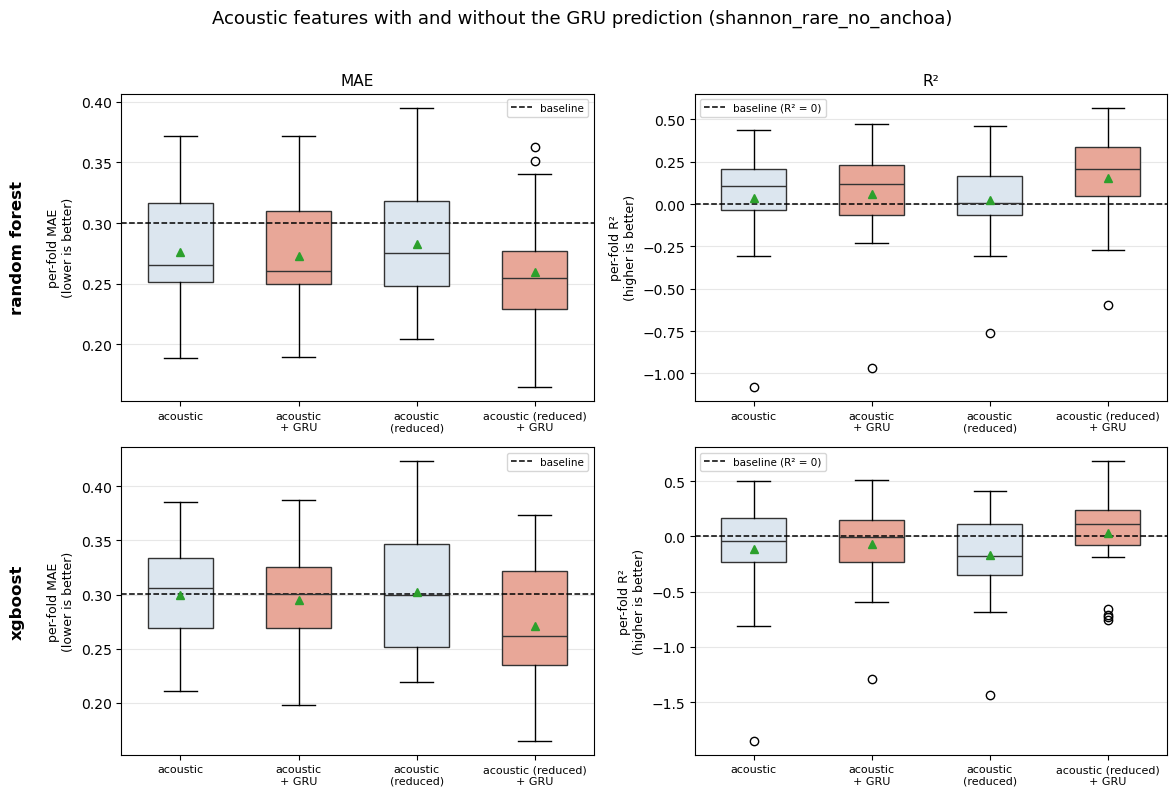

In [ ]:

PANELS = [("mae", "per-fold MAE", "lower is better", base),
          ("r2",  "per-fold R\u00b2",  "higher is better", 0.0)]
FILL = {"acoustic":                 "#DCE6EF", "acoustic + GRU":           "#E8A798",
        "acoustic (reduced)":       "#DCE6EF", "acoustic (reduced) + GRU": "#E8A798"}
LABEL = {"acoustic": "acoustic", "acoustic + GRU": "acoustic\n+ GRU",
         "acoustic (reduced)": "acoustic\n(reduced)",
         "acoustic (reduced) + GRU": "acoustic (reduced)\n+ GRU"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, model in enumerate(MODELS):
    for col, (metric, label, direction, ref) in enumerate(PANELS):
        ax = axes[row, col]
        data = [FL[(FL.model == model) & (FL.features == k)][metric].values for k in order]
        bp = ax.boxplot(data, showmeans=True, patch_artist=True, widths=0.55)
        for patch, k in zip(bp["boxes"], order):
            patch.set_facecolor(FILL[k]); patch.set_edgecolor("#333333")
        for med in bp["medians"]:
            med.set_color("#333333")
        ax.axhline(ref, color="k", ls="--", lw=1.1,
                   label="baseline" if metric != "r2" else "baseline (R\u00b2 = 0)")
        ax.set_xticks(range(1, len(order) + 1))
        ax.set_xticklabels([LABEL[k] for k in order], fontsize=8)
        ax.set_ylabel(f"{label}\n({direction})", fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=7.5, loc="best")
        if row == 0:
            ax.set_title(label.replace("per-fold ", ""), fontsize=11)
    axes[row, 0].annotate(model, xy=(-0.22, 0.5), xycoords="axes fraction",
                          rotation=90, va="center", ha="center",
                          fontsize=12, fontweight="bold")
fig.suptitle(f"Acoustic features with and without the GRU prediction ({TARGET})",
             fontsize=13, y=0.99)
fig.tight_layout(rect=[0.02, 0, 1, 0.97])
fig.savefig(os.path.join(FIG_DIR, "boxplot_feature_sets.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:

print(f"figures: {os.path.relpath(FIG_DIR, BASE)}/")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")

figures: figures/trees/
  boxplot_feature_sets.png
  feature_importance.png
